# DodgerLoopWeekend
# Business Understanding

## Latar Belakang
Dataset DodgerLoopWeekend merupakan data time series yang merepresentasikan
jumlah kendaraan yang melewati loop detector di sekitar Stadion Dodger di California pada 
Weekday dan Weekend.

Tujuan utama klasifikasi ini adalah untuk:
- Mengidentifikasi pola lalu lintas Weekday dan Weekend

## Tujuan Proyek
- Membangun model klasifikasi time series
- Menggunakan algoritma K-Nearest Neighbor dengan Dynamic Time Warping (DTW)
- Menyediakan sistem klasifikasi sederhana yang dapat diakses melalui Gradio


# Data Understanding

## Deskripsi Dataset
Dataset **DodgerLoopWeekend** merupakan dataset time series yang berasal dari
UCR Time Series Classification Archive. Dataset ini merepresentasikan
jumlah kendaraan yang terdeteksi oleh loop detector di sekitar Stadion
Dodger California pada Weekday dan Weekend.

## Tipe Data
- **Jenis data**      : Time Series (univariate)
- **Tipe nilai**      : Numerik (float)
- **Panjang seri**    : Tetap (fixed-length)
- **Jumlah instance** : Relatif kecil (dataset kecil)

## Pengumpulan Data
Data diambil setiap 5 menit dalam 24 jam sehingga terbentuk 288 pengambilan data dalam 1 waktu 24 jam, total 158 data sehingga data diambil selama 158 hari atau sekitar 5 bulan.

## Struktur Data
Setiap baris data memiliki struktur sebagai berikut:
- Kolom ke-1   : Label kelas
- Kolom ke-2 s.d terakhir : Nilai time series (T1, T2, T3, ..., Tn)

Contoh struktur:
| Label | T1 | T2 | T3 | ... | Tn |
|------|----|----|----|-----|----|

## Kelas (Target)
Dataset ini mempunyai 2 kelas yakni:
- **Kelas 1** : Weekday
- **Kelas 2** : Weekend


## Distribusi Data
Jumlah data pada dataset asli:
- Data latih (train) sangat terbatas
- Data uji (test) lebih banyak
Sehingga dilakukan penggabungan data untuk meningkatkan stabilitas model.


Sedang memuat dataset DodgerLoopWeekend...

--- Statistik Awal Data Asli (Sebelum Digabung) ---
Jumlah Train Asli: 20
Jumlah Test Asli : 138
Panjang Series   : 288
Jumlah Channel   : 1 (Univariate)

Kelas yang tersedia: [1 2]


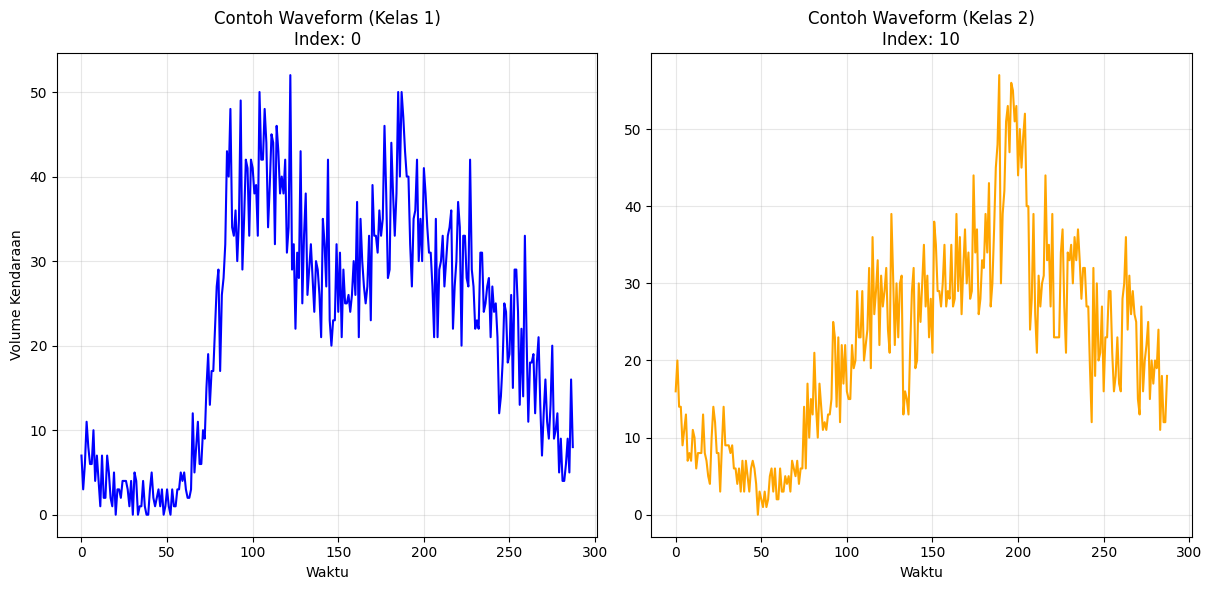

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMinMax

# --- Konfigurasi ---
DATASET_NAME = "DodgerLoopWeekend"

print(f"Sedang memuat dataset {DATASET_NAME}...")

# Menggunakan loader dari tslearn untuk mengambil data UCR secara otomatis
# Jika gagal load online, kamu bisa ganti bagian ini dengan load file lokal
loader = UCR_UEA_datasets()
X_train_org, y_train_org, X_test_org, y_test_org = loader.load_dataset(DATASET_NAME)

print("\n--- Statistik Awal Data Asli (Sebelum Digabung) ---")
print(f"Jumlah Train Asli: {X_train_org.shape[0]}")
print(f"Jumlah Test Asli : {X_test_org.shape[0]}")
print(f"Panjang Series   : {X_train_org.shape[1]}")
print(f"Jumlah Channel   : {X_train_org.shape[2]} (Univariate)")

# --- Analisis Kelas dan Tipe Data ---
unique_classes, counts = np.unique(y_train_org, return_counts=True)
print(f"\nKelas yang tersedia: {unique_classes}")
# Biasanya kelas 1 = Game, 2 = No Game (atau sebaliknya, kita perlu cek dokumentasi/visualisasi)

# Visualisasi Data Mentah
# Mencari index pertama yang mewakili masing-masing kelas untuk sampel
idx_class_1 = np.where(y_train_org == 1)[0][0]
idx_class_2 = np.where(y_train_org == 2)[0][0]

# Ukuran diperlebar lagi (24, 6) agar muat 4 plot dengan jelas
plt.figure(figsize=(24, 6))

# Plot 1: Contoh Waveform Kelas 1
plt.subplot(1, 4, 1)
plt.plot(X_train_org[idx_class_1].ravel(), color='blue')
plt.title(f"Contoh Waveform (Kelas 1)\nIndex: {idx_class_1}")
plt.xlabel("Waktu")
plt.ylabel("Volume Kendaraan")
plt.grid(True, alpha=0.3)

# Plot 2: Contoh Waveform Kelas 2
plt.subplot(1, 4, 2)
plt.plot(X_train_org[idx_class_2].ravel(), color='orange')
plt.title(f"Contoh Waveform (Kelas 2)\nIndex: {idx_class_2}")
plt.xlabel("Waktu")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_7577/937466930.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(x=y_train_org, palette="viridis")
/tmp/ipykernel_7577/937466930.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(x=y_test_org, palette="magma")


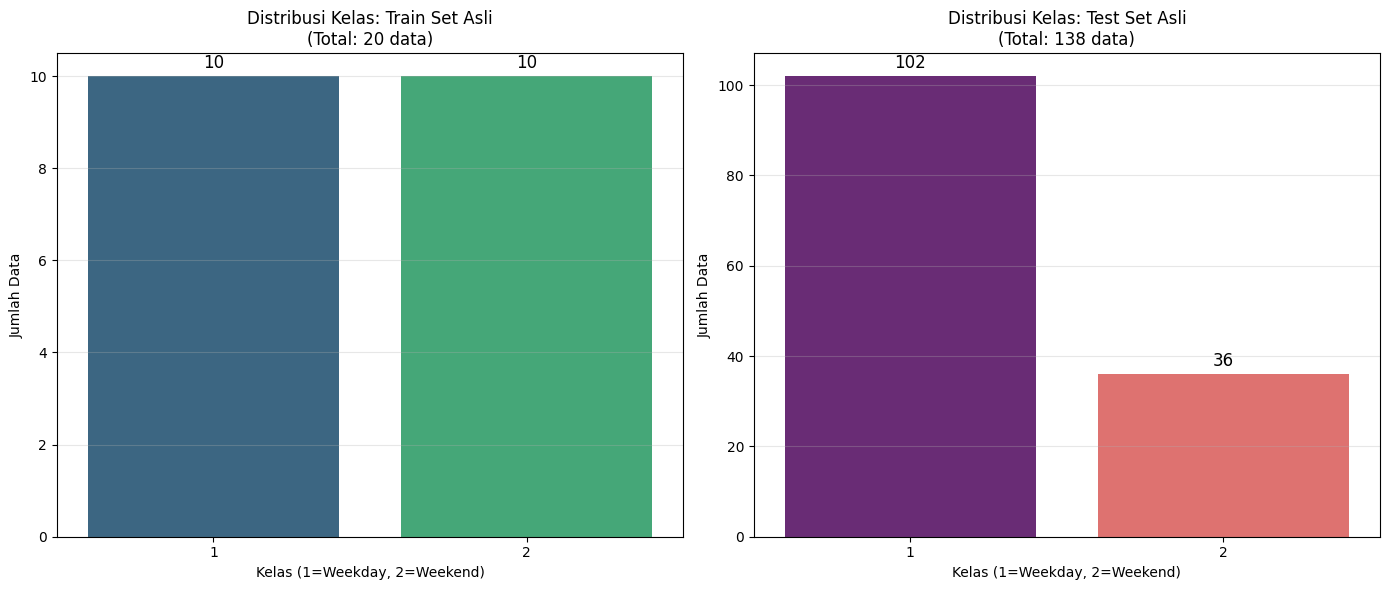

In [6]:
# --- VISUALISASI DISTRIBUSI KELAS (DATA UNDERSTANDING) ---

plt.figure(figsize=(14, 6))

# Plot 1: Distribusi Kelas pada Data TRAIN Asli
plt.subplot(1, 2, 1)
ax1 = sns.countplot(x=y_train_org, palette="viridis")
plt.title(f"Distribusi Kelas: Train Set Asli\n(Total: {len(y_train_org)} data)")
plt.xlabel("Kelas (1=Weekday, 2=Weekend)")
plt.ylabel("Jumlah Data")
plt.grid(axis='y', alpha=0.3)
# Menambahkan angka di atas batang
for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', padding=3, fontsize=12)

# Plot 2: Distribusi Kelas pada Data TEST Asli
plt.subplot(1, 2, 2)
ax2 = sns.countplot(x=y_test_org, palette="magma")
plt.title(f"Distribusi Kelas: Test Set Asli\n(Total: {len(y_test_org)} data)")
plt.xlabel("Kelas (1=Weekday, 2=Weekend)")
plt.ylabel("Jumlah Data")
plt.grid(axis='y', alpha=0.3)
# Menambahkan angka di atas batang
for container in ax2.containers:
    ax2.bar_label(container, fmt='%d', padding=3, fontsize=12)

plt.tight_layout()
plt.show()

# Data Preparation
Di sini kita melakukan preprocessing: penanganan missing values, outlier, normalisasi, dan pembagian data (splitting) sesuai rasio yang kamu minta (70% Train, 20% Test, 10% Implementasi).

In [13]:
import numpy as np
from sklearn.model_selection import train_test_split
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMinMax, TimeSeriesImputer

# --- LOAD DATA ---
print("Sedang memuat dataset...")
loader = UCR_UEA_datasets()
X_train_org, y_train_org, X_test_org, y_test_org = loader.load_dataset("DodgerLoopWeekend")

# 1. PENGGABUNGAN DATA (Merge)
X_total = np.concatenate((X_train_org, X_test_org), axis=0)
y_total = np.concatenate((y_train_org, y_test_org), axis=0)

print(f"Total Data Awal: {X_total.shape[0]} baris")

# 2. PENANGANAN MISSING VALUES (Detail per Kelas & Imputasi)
print("\n--- 2. Analisis Missing Values ---")

# Masking: True jika NaN, False jika ada angka
nan_mask = np.isnan(X_total)
total_nans = np.sum(nan_mask)

if total_nans > 0:
    print(f"Total Missing Values ditemukan: {total_nans} titik data.")
    
    # Mencari lokasi baris yang mengandung NaN
    # nan_indices[0] berisi nomor baris dari setiap titik NaN
    nan_indices = np.where(nan_mask)
    rows_with_nan = nan_indices[0]
    
    # Ambil label kelas untuk setiap titik NaN tersebut
    labels_with_nan = y_total[rows_with_nan]
    
    # Hitung jumlah NaN per kelas
    unique_classes, counts = np.unique(labels_with_nan, return_counts=True)
    
    print("Rincian Missing Values per Kelas:")
    for cls, count in zip(unique_classes, counts):
        print(f"  - Kelas {cls}: {count} nilai hilang")
        
    print(f"\n[Status Data] Sebelum Imputasi: Ada NaN")
    print("Melakukan interpolasi (mengisi data kosong)...")
    
    # Proses Imputasi
    X_total = TimeSeriesImputer(method="linear").fit_transform(X_total)
    
    # Verifikasi ulang
    if not np.isnan(X_total).any():
        print(f"[Status Data] Setelah Imputasi: Bersih (0 NaN)")
else:
    print("Tidak ada Missing Values ditemukan dalam dataset.")


# 3. PENANGANAN OUTLIER
print("\n--- 3. Penanganan Outlier ---")
print(f"[Status Data] Jumlah Baris Sebelum Hapus Outlier: {len(X_total)}")

# Kita hanya akan menyimpan indeks data yang valid (standar deviasi > 0)
valid_indices = []
outlier_count = 0

for i in range(len(X_total)):
    # Jika std deviasi 0 (garis datar/flat), anggap outlier/rusak
    if np.std(X_total[i]) > 0:
        valid_indices.append(i)
    else:
        outlier_count += 1

# Filter data berdasarkan indeks valid
X_total = X_total[valid_indices]
y_total = y_total[valid_indices]

print(f"Ditemukan {outlier_count} data outlier/rusak.")
print(f"[Status Data] Jumlah Baris Setelah Hapus Outlier: {len(X_total)}")


# 4. NORMALISASI (Scaling)
print("\n--- 4. Normalisasi Data ---")
# Jawaban Pertanyaan: Ya, normalisasi ini berlaku untuk data Train DAN Test.
# Karena kita melakukannya pada X_total sebelum di-split.
scaler = TimeSeriesScalerMinMax()
X_total_scaled = scaler.fit_transform(X_total)
print("Normalisasi selesai. Rentang nilai data kini 0 s.d 1.")


# 5. SPLITTING DATA
print("\n--- 5. Pembagian Data (Splitting) ---")
# Split 1: Pisahkan 10% untuk Deploy
X_temp, X_deploy, y_temp, y_deploy = train_test_split(
    X_total_scaled, y_total,
    test_size=0.10,
    random_state=42,
    stratify=y_total
)

# Split 2: Pisahkan Sisa (Temp) menjadi Train (70% total) dan Test (20% total)
ratio_test_from_temp = 0.20 / 0.90
X_train, X_test, y_train, y_test = train_test_split(
    X_temp, y_temp,
    test_size=ratio_test_from_temp,
    random_state=42,
    stratify=y_temp
)

print(f"Train Set (70%)   : {X_train.shape}")
print(f"Test Set (20%)    : {X_test.shape}")
print(f"Deploy Set (10%)  : {X_deploy.shape}")

Sedang memuat dataset...
Total Data Awal: 158 baris

--- 2. Analisis Missing Values ---
Total Missing Values ditemukan: 337 titik data.
Rincian Missing Values per Kelas:
  - Kelas 1: 264 nilai hilang
  - Kelas 2: 73 nilai hilang

[Status Data] Sebelum Imputasi: Ada NaN
Melakukan interpolasi (mengisi data kosong)...
[Status Data] Setelah Imputasi: Bersih (0 NaN)

--- 3. Penanganan Outlier ---
[Status Data] Jumlah Baris Sebelum Hapus Outlier: 158
Ditemukan 0 data outlier/rusak.
[Status Data] Jumlah Baris Setelah Hapus Outlier: 158

--- 4. Normalisasi Data ---
Normalisasi selesai. Rentang nilai data kini 0 s.d 1.

--- 5. Pembagian Data (Splitting) ---
Train Set (70%)   : (110, 288, 1)
Test Set (20%)    : (32, 288, 1)
Deploy Set (10%)  : (16, 288, 1)


# Modelling
Kita menggunakan algoritma k-Nearest Neighbors (k-NN) dengan metrik jarak Dynamic Time Warping (DTW). DTW dipilih karena lebih tahan terhadap pergeseran waktu (time shift) dibandingkan Euclidean distance biasa, yang sangat penting untuk data lalu lintas.

In [30]:
from tslearn.neighbors import KNeighborsTimeSeriesClassifier

# Setup Model
# n_neighbors=3 adalah standar awal yang baik untuk dataset kecil
# metric='dtw' adalah kunci dari time series classification
knn_dtw = KNeighborsTimeSeriesClassifier(n_neighbors=3, metric="dtw")

print("Sedang melatih model KNN-DTW... (Mungkin memakan waktu tergantung data)")
knn_dtw.fit(X_train, y_train)
print("Pelatihan selesai.")

Sedang melatih model KNN-DTW... (Mungkin memakan waktu tergantung data)
Pelatihan selesai.


# Evaluasi

Akurasi Model pada Data Test: 1.00 (100.00%)

--- Laporan Klasifikasi ---
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        23
           2       1.00      1.00      1.00         9

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32



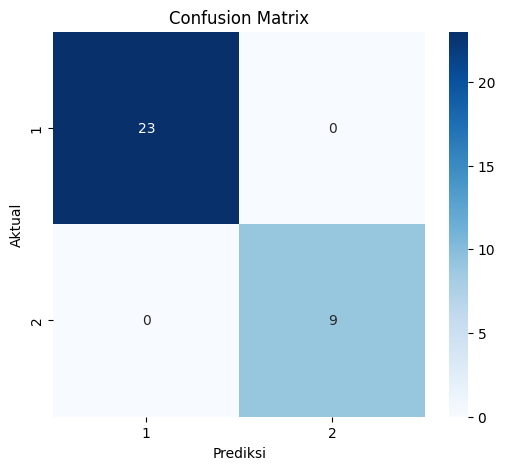

In [31]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Prediksi data test
y_pred = knn_dtw.predict(X_test)

# Hitung Akurasi
acc = accuracy_score(y_test, y_pred)
print(f"Akurasi Model pada Data Test: {acc:.2f} ({acc*100:.2f}%)")

# Classification Report
print("\n--- Laporan Klasifikasi ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_classes, yticklabels=unique_classes)
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

#  - (Ini adalah placeholder tag, gambar akan dihasilkan oleh kode di atas)

# Deployment

Kita akan menggunakan Gradio untuk membuat antarmuka web sederhana. Karena inputnya berupa deret angka (time series), kita akan membuat fitur dimana user bisa memilih "Contoh Data" dari simpanan data Deploy (10%) atau memasukkan angka secara manual.

https://huggingface.co/spaces/itssreii/dodgerloopweekend

In [ ]:
import gradio as gr
import matplotlib.pyplot as plt
import re  # Import modul Regex untuk pemisahan teks yang lebih canggih

# --- FUNGSI KLASIFIKASI SUPER FLEKSIBEL ---
def classify_traffic(input_text, use_example_idx):
    try:
        data_to_predict = None
        input_source = ""
        actual_label = "-"

        # 1. Cek Input Manual Terlebih Dahulu
        if input_text is not None and input_text.strip() != "":
            try:
                # --- LOGIKA BARU: MEMISAHKAN ANGKA ---
                # re.split akan memotong teks berdasarkan:
                # [,\s\n]+  --> Koma, Spasi, atau Enter (Newline)
                # input_text.strip() untuk buang spasi di awal/akhir
                
                raw_values = re.split(r'[,\s\n\t]+', input_text.strip())
                
                # Filter: Hapus string kosong jika ada (akibat spasi ganda dsb)
                values = [float(x) for x in raw_values if x != ""]
                
                if len(values) == 0:
                    return "Error: Tidak ada angka yang terbaca.", None

                # Reshape ke format model (Batch, Length, Channel)
                data_arr = np.array(values).reshape(1, -1, 1)
                
                data_to_predict = data_arr
                actual_label = "Tidak diketahui (Input Manual)"
                input_source = "Input Manual (Fleksibel)"
                
            except ValueError:
                return "Error: Input mengandung huruf atau simbol yang bukan angka.", None

        # 2. Jika Input Manual kosong, Cek Index
        elif use_example_idx is not None:
            idx = int(use_example_idx)
            if idx < 0 or idx >= len(X_deploy):
                return f"Error: Index {idx} di luar jangkauan (0 - {len(X_deploy)-1}).", None
            
            data_to_predict = X_deploy[idx].reshape(1, -1, 1)
            actual_label = str(y_deploy[idx])
            input_source = f"Data Implementasi Index ke-{idx}"
        
        else:
            return "Mohon isi Input Manual atau Pilih Index.", None

        # --- Lakukan Prediksi ---
        prediction = knn_dtw.predict(data_to_predict)[0]
        
        # --- Plotting ---
        fig = plt.figure(figsize=(10, 4))
        plt.plot(data_to_predict[0].ravel(), color='blue', label='Input Series')
        plt.title(f"Waveform Input\nPrediksi Model: KELAS {prediction}")
        plt.xlabel("Waktu")
        plt.ylabel("Volume")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        
        plot_path = "prediction_plot_flex.png"
        plt.savefig(plot_path)
        plt.close()

        result_text = (
            f"Sumber Data: {input_source}\n"
            f"Panjang Data: {data_to_predict.shape[1]} titik waktu\n"
            f"Label Asli (jika ada): {actual_label}\n"
            f"----------------------------------\n"
            f"HASIL PREDIKSI: KELAS {prediction}\n"
        )
        
        return result_text, plot_path

    except Exception as e:
        return f"System Error: {str(e)}", None

# --- ANTARMUKA GRADIO ---
with gr.Blocks() as demo:
    gr.Markdown("# Klasifikasi Time Series: DodgerLoopWeekend")
    
    with gr.Row():
        with gr.Column():
            inp_text = gr.Textbox(
                label="1. Input Manual (Bebas Format: Spasi/Koma/Enter)", 
                placeholder="Paste data angka di sini...",
                lines=8
            )
            inp_idx = gr.Number(
                label="2. Atau Gunakan Index Data Deploy", 
                value=None,
                precision=0
            )
            btn = gr.Button("Prediksi", variant="primary")
            
        with gr.Column():
            out_text = gr.Textbox(label="Hasil Analisis")
            out_plot = gr.Image(label="Visualisasi Sinyal")

    btn.click(fn=classify_traffic, inputs=[inp_text, inp_idx], outputs=[out_text, out_plot])

print("Menjalankan Gradio...")
demo.launch()

Menjalankan Gradio...
* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.
